# 02 — EDA Sondajes Diamantina
**Objetivo:** Caracterizar los sondajes históricos de diamantina — distribución espacial, perfiles de ley CU en profundidad, litología.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')

DRILL_PATH = Path('../Documentacion/Referencias/Datos Demo/Data_drill')

collar  = pd.read_csv(DRILL_PATH / 'collar.csv')
assay   = pd.read_csv(DRILL_PATH / 'assay.csv')
lith    = pd.read_csv(DRILL_PATH / 'lith.csv')
drlrun  = pd.read_csv(DRILL_PATH / 'drlrun.csv')
sg      = pd.read_csv(DRILL_PATH / 'sg.csv')
survey  = pd.read_csv(DRILL_PATH / 'survey.csv')

print(f'Collar: {collar.shape} | Assay: {assay.shape} | Lith: {lith.shape}')
print(f'DrlRun: {drlrun.shape} | SG: {sg.shape} | Survey: {survey.shape}')

Collar: (301, 13) | Assay: (32195, 37) | Lith: (28395, 6)
DrlRun: (0, 4) | SG: (4437, 6) | Survey: (16864, 4)


/tmp/ipykernel_94846/1727449291.py:12: DtypeWarning: Columns (0: AG) have mixed types. Specify dtype option on import or set low_memory=False.
  assay   = pd.read_csv(DRILL_PATH / 'assay.csv')


## 1. Perfil de profundidades

       TOTALD       RL
count  301.00   301.00
mean   212.83  4562.85
std     84.71    39.52
min     32.00  4463.84
25%    157.90  4540.39
50%    209.90  4567.21
75%    255.40  4592.70
max    823.30  4642.88


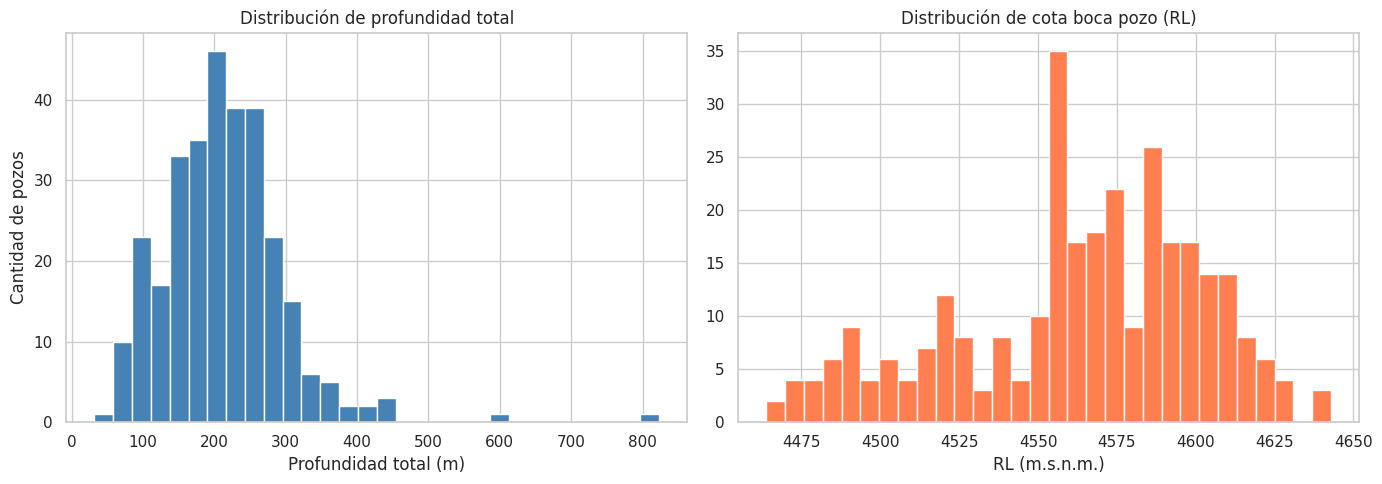

In [2]:
print(collar[['TOTALD', 'RL']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

collar['TOTALD'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de profundidad total')
axes[0].set_xlabel('Profundidad total (m)')
axes[0].set_ylabel('Cantidad de pozos')

collar['RL'].hist(bins=30, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Distribución de cota boca pozo (RL)')
axes[1].set_xlabel('RL (m.s.n.m.)')

plt.tight_layout()
plt.show()

## 2. Mapa planta — collares diamantina vs BH

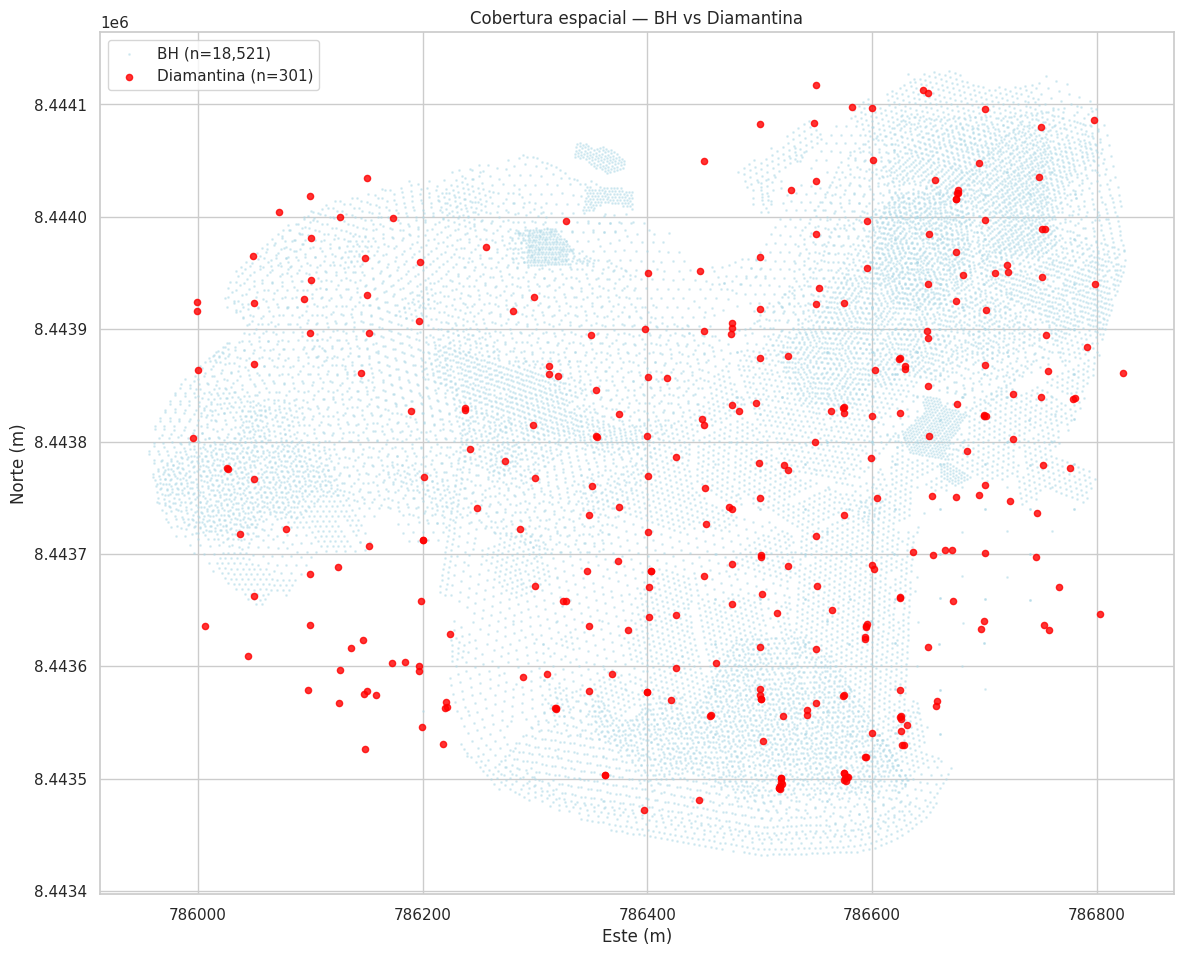

In [3]:
bh_collar = pd.read_csv(
    Path('../Documentacion/Referencias/Datos Demo/Data_BH/collar.csv'),
    usecols=['EAST', 'NORTH'])

fig, ax = plt.subplots(figsize=(12, 10))

ax.scatter(bh_collar['EAST'], bh_collar['NORTH'], s=1, color='lightblue',
           alpha=0.4, label=f'BH (n={len(bh_collar):,})')
ax.scatter(collar['EAST'], collar['NORTH'], s=20, color='red',
           alpha=0.8, label=f'Diamantina (n={len(collar)})', zorder=5)

ax.set_xlabel('Este (m)')
ax.set_ylabel('Norte (m)')
ax.set_title('Cobertura espacial — BH vs Diamantina')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 3. Perfil de ley CU en profundidad (desde-hasta)

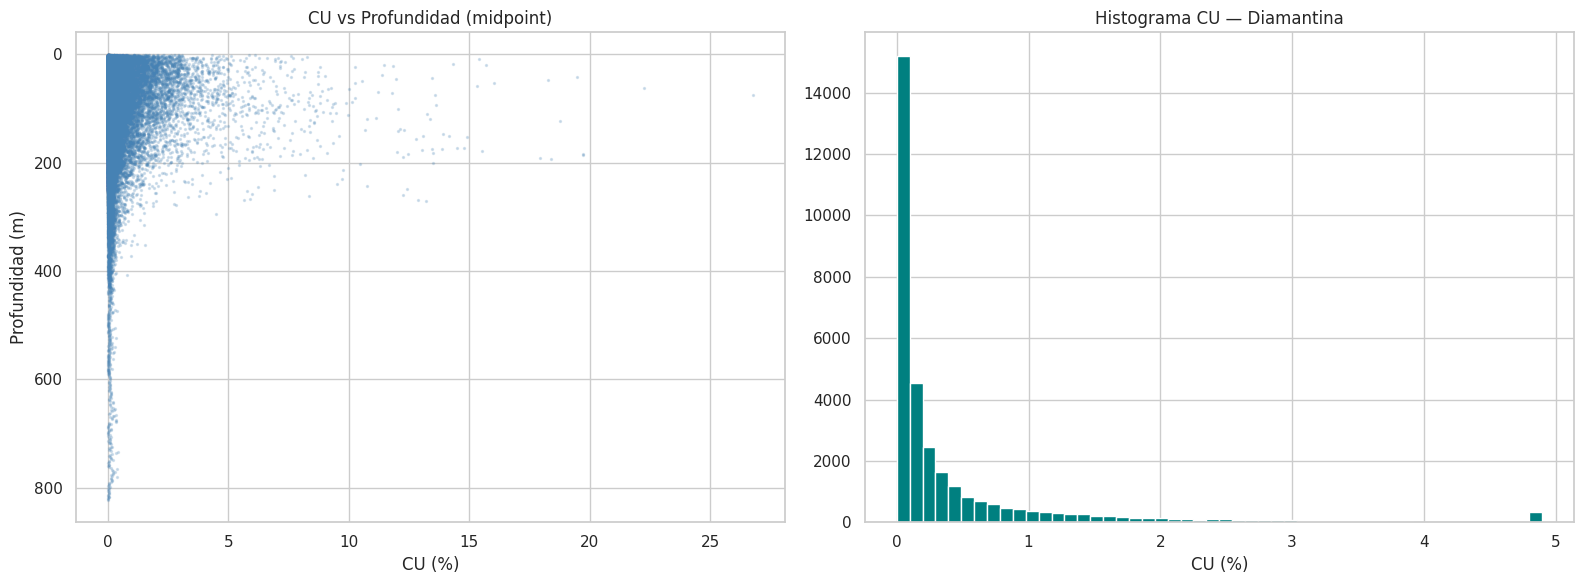

count    32195.0000
mean         0.4667
std          1.0741
min          0.0003
25%          0.0270
50%          0.1116
75%          0.4140
max         26.7700
Name: CU, dtype: float64


In [4]:
assay_cu = assay.dropna(subset=['CU']).copy()
assay_cu['depth_mid'] = (assay_cu['FROM'] + assay_cu['TO']) / 2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Perfil promedio CU vs profundidad
assay_cu.plot.scatter(x='CU', y='depth_mid', ax=axes[0], s=2, alpha=0.2, color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('CU vs Profundidad (midpoint)')
axes[0].set_xlabel('CU (%)')
axes[0].set_ylabel('Profundidad (m)')

# Histograma CU
assay_cu['CU'].clip(upper=assay_cu['CU'].quantile(0.99)).hist(
    bins=50, ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Histograma CU — Diamantina')
axes[1].set_xlabel('CU (%)')

plt.tight_layout()
plt.show()
print(assay_cu['CU'].describe().round(4))

## 4. Litología y zona oxidación

In [5]:
print('Litologías (LITH2):')
print(lith['LITH2'].value_counts().head(15))
print('\nZona oxidación (OXDOM):')
print(lith['OXDOM'].value_counts())

Litologías (LITH2):
LITH2
GSK    10390
MZQ     4473
EPG     2618
MZH     2411
MZB     2403
MSK     2040
PSK     1062
EGT      778
EEP      625
HFL      507
BX       293
QT       202
QFP      161
MZM       78
ESK       75
Name: count, dtype: int64

Zona oxidación (OXDOM):
Series([], Name: count, dtype: int64)


## 5. Gravedad específica por litología

In [6]:
sg_lith = sg.merge(lith[['HOLEID', 'FROM', 'TO', 'LITH2']], on=['HOLEID', 'FROM', 'TO'], how='left')

sg_col = [c for c in sg.columns if 'sg' in c.lower() or 'density' in c.lower() or 'SG' in c]
print('Columna SG detectada:', sg_col)
print(sg.columns.tolist())
sg.describe().round(3)

Columna SG detectada: ['SGCALC']
['HOLEID', 'FROM', 'TO', 'TYPE', 'SGCALC', 'SAMPLE']


,FROM,TO,SGCALC
count,4437.000,4437.000,4437.000
mean,118.787,120.331,3.262
std,85.007,85.043,0.521
min,2.000,4.000,2.116
25%,54.100,55.300,2.665
50%,104.450,106.000,3.390
75%,168.000,169.900,3.594
max,809.800,809.900,4.757
